In [ ]:
!pip install unsloth
!pip install --upgrade trl>=0.14.0
!pip install chromadb sentence-transformers datasets matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.

In [ ]:
!git clone https://github.com/Harshitawake/tool-call-rl-OpenEnv.git /content/tool-call-rl-OpenEnv
%cd /content/tool-call-rl-OpenEnv

Cloning into '/content/tool-call-rl-OpenEnv'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 55 (delta 9), reused 52 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 245.72 KiB | 17.55 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/tool-call-rl-OpenEnv


In [ ]:
# ============================================================
# CELL 3: Configuration
# ============================================================
import json
import os
import re
import sys
import torch
from pathlib import Path

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

MODEL_ID = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 2048
LORA_R = 16
LORA_ALPHA = 16

NUM_GENERATIONS = 4
MAX_COMPLETION_LENGTH = 256
LEARNING_RATE = 5e-6
NUM_TRAIN_EPOCHS = 1
BATCH_SIZE = 2
GRADIENT_ACCUMULATION = 2
LOGGING_STEPS = 5
SAVE_STEPS = 50

EVAL_SCENARIOS = 40
TRAIN_SCENARIOS = 40

SAVE_DIR = "./grpo_checkpoints"
PLOTS_DIR = "./plots"

In [ ]:
# ============================================================
# CELL 4: Load model with Unsloth
# ============================================================
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    MODEL_ID,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

print(f"Model loaded: {MODEL_ID}")
model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model loaded: unsloth/Qwen2.5-3B-Instruct-bnb-4bit
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [ ]:
# ============================================================
# CELL 5: Load environment data
# ============================================================

sys.path.insert(0, str(Path(".").resolve()))

DATA_PATH = Path("data/scenarios_expanded.json")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/scenarios.json")
if not DATA_PATH.exists():
    DATA_PATH = Path("/content/tool-call-rl-OpenEnv/data/scenarios_expanded.json")
if not DATA_PATH.exists():
    DATA_PATH = Path("/content/tool-call-rl-OpenEnv/data/scenarios.json")

with open(DATA_PATH) as f:
    data = json.load(f)

ALL_TOOLS = data["tools"]
TOOL_LOOKUP = {t["name"]: t for t in ALL_TOOLS}

SCENARIOS = []
LABELS = {}
for s in data["scenarios"]:
    s_copy = dict(s)
    label = s_copy.pop("label")
    SCENARIOS.append(s_copy)
    LABELS[s_copy["id"]] = label

print(f"Loaded {len(SCENARIOS)} scenarios from {DATA_PATH.name}")
print(f"Tools available: {len(ALL_TOOLS)}")
print(f"Will train on first {TRAIN_SCENARIOS}, evaluate on first {EVAL_SCENARIOS}")


Loaded 137 scenarios from scenarios_expanded.json
Tools available: 16
Will train on first 40, evaluate on first 40


In [ ]:
# ============================================================
# CELL 6: Define reward function
# ============================================================

def extract_json_from_text(text: str) -> dict:
    try:
        return json.loads(text.strip())
    except Exception:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except Exception:
                pass
    return {}


def grade_completion(completion_text: str, scenario: dict, task_type: str = "hard") -> float:
    label = LABELS.get(scenario["id"])
    if label is None:
        return 0.0

    parsed = extract_json_from_text(completion_text)
    tool_calls = parsed.get("tool_calls", [])
    should_refuse = parsed.get("should_refuse", False)

    expected_calls = label["expected_tool_calls"]
    expected_refuse = label["should_refuse"]
    required_params = label.get("required_params", {})
    chain_order_matters = label.get("chain_order_matters", False)
    available_tools = scenario.get("available_tools", [])

    reward = 0.0

    if expected_refuse:
        if should_refuse or len(tool_calls) == 0:
            return 1.0
        return 0.0

    if (should_refuse or len(tool_calls) == 0) and expected_calls:
        return 0.0

    expected_names = [tc["tool_name"] for tc in expected_calls]
    actual_names = [tc.get("tool_name", "") for tc in tool_calls]

    correct_tools = set(expected_names) & set(actual_names)
    tool_score = len(correct_tools) / max(len(expected_names), 1)
    reward += 0.25 * tool_score

    param_scores = []
    for exp_call in expected_calls:
        exp_name = exp_call["tool_name"]
        matching = [tc for tc in tool_calls if tc.get("tool_name") == exp_name]
        if matching:
            params = matching[0].get("parameters", {})
            exp_params = exp_call.get("parameters", {})
            req = required_params.get(exp_name, [])
            total = max(len(req), 1)
            ps = 0.0
            for pname in req:
                if pname in params:
                    ps += 0.5
                    exp_val = exp_params.get(pname)
                    act_val = params.get(pname)
                    if exp_val is not None and not str(exp_val).startswith("<"):
                        a = str(act_val).strip().lower() if act_val else ""
                        e = str(exp_val).strip().lower()
                        if a == e or (len(e) > 10 and (e in a or a in e)):
                            ps += 0.5
            param_scores.append(ps / total)
        else:
            param_scores.append(0.0)

    if param_scores:
        reward += 0.30 * (sum(param_scores) / len(param_scores))

    if chain_order_matters and len(expected_calls) > 1:
        positions = []
        for exp_name in expected_names:
            for i, act in enumerate(actual_names):
                if act == exp_name:
                    positions.append(i)
                    break
            else:
                positions.append(-1)
        valid_pos = [p for p in positions if p >= 0]
        if len(valid_pos) <= 1:
            order_score = 1.0 if valid_pos else 0.0
        else:
            order_score = 1.0 if all(valid_pos[i] < valid_pos[i+1] for i in range(len(valid_pos)-1)) else 0.2
        order_score *= len(valid_pos) / len(expected_names) if valid_pos else 0
        reward += 0.20 * order_score
    else:
        reward += 0.20 * tool_score

    extra = [n for n in actual_names if n not in expected_names]
    if not extra:
        reward += 0.10
    else:
        reward -= 0.05 * len(extra)

    if len(actual_names) == len(expected_names):
        reward += 0.15
    else:
        reward -= 0.05 * abs(len(actual_names) - len(expected_names))

    for name in actual_names:
        if name not in available_tools:
            reward -= 0.4

    return max(0.0, min(1.0, reward))


In [ ]:
# ============================================================
# CELL 7: Build prompts for GRPO
# ============================================================

SYSTEM_PROMPT = """You are an AI agent that decides which tools to call for a given user query.

RULES:
1. Pick the correct tool(s) and provide the correct parameters.
2. For multi-step tasks, list tool calls in the correct execution order.
3. If the query is dangerous (data deletion, injection), REFUSE.
4. If no tool is needed, REFUSE.
5. Never call tools not in the available list.

Respond ONLY in JSON:
{"should_refuse": false, "reasoning": "...", "tool_calls": [{"tool_name": "...", "parameters": {...}}]}
If refusing:
{"should_refuse": true, "reasoning": "...", "tool_calls": []}"""


def build_prompt_for_scenario(scenario: dict, lessons_text: str = "") -> str:
    available = scenario.get("available_tools", [])
    tool_defs = [TOOL_LOOKUP[t] for t in available if t in TOOL_LOOKUP]

    tools_block = ""
    for td in tool_defs:
        params = ", ".join(
            f"{p['name']}: {p['type']}{' (REQUIRED)' if p.get('required', True) else ''}"
            for p in td.get("parameters", [])
        )
        tools_block += f"  {td['name']}: {td['description']} [{params}]\n"

    query = scenario.get("user_query", "")
    context = scenario.get("context", "")
    ctx_str = f"\nContext: {context}" if context else ""

    prompt = f"USER QUERY: {query}{ctx_str}\n\nAVAILABLE TOOLS:\n{tools_block}"

    if lessons_text:
        prompt += f"\n{lessons_text}\n\nUse these lessons to guide your decision."

    prompt += "\n\nDecide which tool(s) to call (or refuse). Respond in JSON."
    return prompt


def create_dataset(scenarios: list, lessons_fn=None):
    from datasets import Dataset

    items = []
    for scenario in scenarios:
        lessons = ""
        if lessons_fn:
            lessons = lessons_fn(scenario.get("user_query", ""))

        prompt = build_prompt_for_scenario(scenario, lessons)

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]

        items.append({
            "prompt": tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            ),
            "scenario_id": scenario["id"],
        })

    return Dataset.from_list(items)


dataset_r1 = create_dataset(SCENARIOS[:TRAIN_SCENARIOS])
print(f"Round 1 dataset: {len(dataset_r1)} examples (of {len(SCENARIOS)} total)")
print(f"Sample prompt (truncated):\n{dataset_r1[0]['prompt'][:500]}...")


Round 1 dataset: 40 examples (of 137 total)
Sample prompt (truncated):
<|im_start|>system
You are an AI agent that decides which tools to call for a given user query.

RULES:
1. Pick the correct tool(s) and provide the correct parameters.
2. For multi-step tasks, list tool calls in the correct execution order.
3. If the query is dangerous (data deletion, injection), REFUSE.
4. If no tool is needed, REFUSE.
5. Never call tools not in the available list.

Respond ONLY in JSON:
{"should_refuse": false, "reasoning": "...", "tool_calls": [{"tool_name": "...", "parameter...


In [ ]:
# ============================================================
# CELL 8: Define TRL reward function
# ============================================================

SCENARIO_MAP = {s["id"]: s for s in SCENARIOS}


def reward_fn(completions, scenario_id=None, **kwargs):
    rewards = []
    for i, completion in enumerate(completions):
        sid = None
        if scenario_id is not None and i < len(scenario_id):
            sid = scenario_id[i]

        if sid and sid in SCENARIO_MAP:
            scenario = SCENARIO_MAP[sid]
        else:
            scenario = SCENARIOS[i % len(SCENARIOS)]

        reward = grade_completion(completion, scenario, task_type="hard")
        rewards.append(reward)

    return rewards


test_rewards = reward_fn(
    ['{"should_refuse": true, "reasoning": "dangerous", "tool_calls": []}'],
    scenario_id=[SCENARIOS[4]["id"]]
)
print(f"Reward function test (refusal scenario): {test_rewards}")


Reward function test (refusal scenario): [1.0]


In [ ]:
# ============================================================
# CELL 9: Pre-training baseline evaluation
# ============================================================

def evaluate_model(scenarios, lessons_fn=None, label="EVAL"):
    """Reusable evaluation function for any stage."""
    FastLanguageModel.for_inference(model)

    rewards = []
    experiences = []
    for scenario in scenarios:
        lessons = lessons_fn(scenario["user_query"]) if lessons_fn else ""
        prompt = build_prompt_for_scenario(scenario, lessons)
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]

        input_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=1536).to(model.device)

        completion = ""
        tool_names = []
        parsed = {}

        try:
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=MAX_COMPLETION_LENGTH,
                    temperature=0.3,
                    do_sample=True,
                )

            completion = tokenizer.decode(
                outputs[0][inputs["input_ids"].shape[-1]:],
                skip_special_tokens=True,
            )
            reward = grade_completion(completion, scenario)
            parsed = extract_json_from_text(completion)
            tool_names = [tc.get("tool_name", "") for tc in parsed.get("tool_calls", [])]
        except Exception as e:
            print(f"  Scenario {scenario['id']:3d} | ERROR: {str(e)[:60]}")
            reward = 0.0

        rewards.append(reward)
        experiences.append({
            "query": scenario["user_query"],
            "scenario_id": scenario["id"],
            "tool_sequence": tool_names,
            "reward": reward,
            "should_refuse": parsed.get("should_refuse", False),
        })
        print(f"  Scenario {scenario['id']:3d} | {str(tool_names):40s} | reward={reward:.2f}")

    avg = sum(rewards) / len(rewards)
    acc = sum(1 for r in rewards if r > 0.7) / len(rewards)
    print(f"\n{label}: avg_reward={avg:.3f}, accuracy={acc:.1%}")
    return rewards, experiences, avg, acc


print("=" * 60)
print("BASELINE EVALUATION (before any training)")
print("=" * 60)

baseline_rewards, _, avg_baseline, acc_baseline = evaluate_model(
    SCENARIOS[:EVAL_SCENARIOS], label="BASELINE"
)
print("=" * 60)


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASELINE EVALUATION (before any training)


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

  Scenario   1 | ['get_weather']                          | reward=1.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  Scenario  37 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  38 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  39 | []                                       | reward=0.00
  Scenario  40 | []                                       | reward=0.00

BASELINE: avg_reward=0.526, accuracy=50.0%


In [ ]:
# ============================================================
# CELL 10: Train with GRPO - Round 1
# ============================================================
from trl import GRPOTrainer, GRPOConfig

FastLanguageModel.for_training(model)

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

training_args = GRPOConfig(
    output_dir=f"{SAVE_DIR}/round1",
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    remove_unused_columns=False,
)

trainer_r1 = GRPOTrainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    reward_funcs=reward_fn,
    train_dataset=dataset_r1,
)

print(f"Training on {len(dataset_r1)} scenarios...")
train_result_r1 = trainer_r1.train()
print(f"Round 1 complete. Loss: {train_result_r1.training_loss:.4f}")

model.save_pretrained(f"{SAVE_DIR}/round1_adapter")
tokenizer.save_pretrained(f"{SAVE_DIR}/round1_adapter")
print(f"Round 1 adapter saved to {SAVE_DIR}/round1_adapter")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Training on 40 scenarios...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 40 | Num Epochs = 1 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attentio

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,0.013809,0.675250,0.039007,105.950000,94.200000,127.600000,0.000000,105.950000,94.200000,127.600000,0.000013,0.675250,0.039007
10,0.006862,0.701250,0.378440,105.800000,81.800000,135.200000,0.000000,105.800000,81.800000,135.200000,0.000016,0.701250,0.378440
15,0.033724,0.530500,0.256077,153.400000,119.200000,186.800000,0.100000,147.333334,119.200000,179.400000,0.000024,0.530500,0.256077
20,-0.040136,0.576000,0.167928,69.050000,51.600000,88.400000,0.000000,69.050000,51.600000,88.400000,0.000070,0.576000,0.167928
25,0.000000,0.786250,0.000000,84.900000,78.200000,96.000000,0.000000,84.900000,78.200000,96.000000,0.000035,0.786250,0.000000
30,0.030552,0.415625,0.178174,130.750000,104.600000,154.800000,0.050000,127.550000,104.600000,146.000000,0.000037,0.415625,0.178174
35,0.000890,0.783750,0.191452,106.450000,76.200000,129.000000,0.050000,101.433334,76.200000,125.000000,0.000138,0.783750,0.191452
40,-0.019279,0.673750,0.149455,103.650000,69.600000,137.800000,0.050000,98.683334,69.600000,124.400000,0.000046,0.673750,0.149455


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2

Round 1 complete. Loss: 0.0033


Unsloth: Restored added_tokens_decoder metadata in ./grpo_checkpoints/round1_adapter/tokenizer_config.json.


Round 1 adapter saved to ./grpo_checkpoints/round1_adapter


In [ ]:
# ============================================================
# CELL 11: Evaluate Round 1 & collect experiences
# ============================================================

print("=" * 60)
print("ROUND 1 EVALUATION (after GRPO training)")
print("=" * 60)

rewards_r1, experiences_r1, avg_r1, acc_r1 = evaluate_model(
    SCENARIOS[:EVAL_SCENARIOS], label="ROUND 1"
)
print(f"Improvement over baseline: {avg_r1 - avg_baseline:+.3f}")
print("=" * 60)

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ROUND 1 EVALUATION (after GRPO training)


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario   1 | ['get_weather']                          | reward=1.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  Scenario  37 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  38 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  39 | ['web_search', 'generate_summary', 'translate_text', 'file_write'] | reward=0.89
  Scenario  40 | []                                       | reward=0.00

ROUND 1: avg_reward=0.610, accuracy=57.5%
Improvement over baseline: +0.085


In [ ]:
sys.path.insert(0, ".")

In [ ]:
import os
print("Current dir:", os.getcwd())
print("memory/ exists:", os.path.exists("memory"))
print("memory/memory_store.py exists:", os.path.exists("memory/memory_store.py"))

# Force the path
import sys
sys.path.insert(0, os.getcwd())

# If still in wrong directory, fix it:
if not os.path.exists("memory"):
    os.chdir("/content/tool-call-rl-OpenEnv")
    sys.path.insert(0, os.getcwd())
    print("Changed to:", os.getcwd())

# Now import
from memory.memory_store import MemoryStore
memory = MemoryStore(persist_dir="./data/chroma_data")
print(f"Memory store ready! ({memory.count()} entries)")

Current dir: /content
memory/ exists: False
memory/memory_store.py exists: False
Changed to: /content/tool-call-rl-OpenEnv
Memory store ready! (0 entries)


In [ ]:
# ============================================================
# CELL 12: Store experiences to ChromaDB memory
# ============================================================

# from memory.memory_store import MemoryStore

# memory = MemoryStore(persist_dir="./data/chroma_data")

for exp in experiences_r1:
    tools_str = " -> ".join(exp["tool_sequence"]) if exp["tool_sequence"] else "REFUSED"
    outcome = "good" if exp["reward"] > 0.7 else "poor"
    lesson = f"For query like '{exp['query'][:50]}...', sequence [{tools_str}] was {outcome}"

    memory.store_experience(
        query=exp["query"],
        scenario_id=exp["scenario_id"],
        tool_sequence=exp["tool_sequence"],
        reward=exp["reward"],
        lesson=lesson,
        should_refuse=exp["should_refuse"],
        difficulty="hard",
        episode=1,
    )

print(f"Stored {memory.count()} experiences in memory")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:07<00:00, 11.5MiB/s]


Stored 40 experiences in memory


In [ ]:

# ============================================================
# CELL 13: Build Round 2 dataset (with lessons from memory)
# ============================================================

FastLanguageModel.for_training(model)


def get_lessons(query: str) -> str:
    return memory.format_lessons_for_prompt(query, n_results=3)


dataset_r2 = create_dataset(SCENARIOS[:TRAIN_SCENARIOS], lessons_fn=get_lessons)
print(f"Round 2 dataset: {len(dataset_r2)} examples")



Round 2 dataset: 40 examples


In [ ]:

# ============================================================
# CELL 14: Train with GRPO - Round 2 (with lessons)
# ============================================================

training_args_r2 = GRPOConfig(
    output_dir=f"{SAVE_DIR}/round2",
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE * 0.5,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    remove_unused_columns=False,
)

trainer_r2 = GRPOTrainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args_r2,
    reward_funcs=reward_fn,
    train_dataset=dataset_r2,
)

print("Starting GRPO Round 2 training (with lessons)...")
train_result_r2 = trainer_r2.train()
print(f"Round 2 complete. Loss: {train_result_r2.training_loss:.4f}")

model.save_pretrained(f"{SAVE_DIR}/round2_adapter")
tokenizer.save_pretrained(f"{SAVE_DIR}/round2_adapter")
print(f"Round 2 adapter saved to {SAVE_DIR}/round2_adapter")



Starting GRPO Round 2 training (with lessons)...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 40 | Num Epochs = 1 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,0.029334,0.605167,0.127615,130.650000,95.800000,156.200000,0.050000,128.800000,95.800000,156.200000,0.000081,0.605167,0.127615
10,0.014941,0.907083,0.148277,101.400000,74.000000,132.000000,0.000000,101.400000,74.000000,132.000000,0.000064,0.907083,0.148277
15,-0.071066,0.534917,0.082568,143.200000,97.600000,184.600000,0.150000,133.383334,97.600000,172.200000,0.000048,0.534917,0.082568
20,-0.002761,0.400125,0.060250,89.250000,69.800000,124.000000,0.050000,85.433334,69.800000,110.000000,0.000093,0.400125,0.060250
25,0.001587,0.939687,0.093125,73.450000,54.400000,88.400000,0.050000,71.066669,54.400000,86.800000,0.000034,0.939687,0.093125
30,-0.028922,0.595125,0.067083,140.300000,115.600000,159.400000,0.000000,140.300000,115.600000,159.400000,0.000047,0.595125,0.067083
35,0.026947,0.778125,0.028750,111.100000,90.400000,138.800000,0.000000,111.100000,90.400000,138.800000,0.000093,0.778125,0.028750
40,-0.085348,0.691250,0.132367,107.500000,57.400000,153.800000,0.100000,97.600000,57.400000,141.200000,0.000099,0.691250,0.132367


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Round 2 complete. Loss: -0.0144


Unsloth: Restored added_tokens_decoder metadata in ./grpo_checkpoints/round2_adapter/tokenizer_config.json.


Round 2 adapter saved to ./grpo_checkpoints/round2_adapter


In [ ]:

# ============================================================
# CELL 15: Evaluate Round 2
# ============================================================

print("=" * 60)
print("ROUND 2 EVALUATION (GRPO + lessons from memory)")
print("=" * 60)

rewards_r2, experiences_r2, avg_r2, acc_r2 = evaluate_model(
    SCENARIOS[:EVAL_SCENARIOS], lessons_fn=get_lessons, label="ROUND 2"
)
print(f"Improvement over Round 1: {avg_r2 - avg_r1:+.3f}")
print(f"Improvement over baseline: {avg_r2 - avg_baseline:+.3f}")
print("=" * 60)



ROUND 2 EVALUATION (GRPO + lessons from memory)


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


  Scenario   1 | ['get_weather']                          | reward=1.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario   2 | ['search_flights']                       | reward=0.95


...

  Scenario  38 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  39 | []                                       | reward=0.00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Scenario  40 | []                                       | reward=0.00

ROUND 2: avg_reward=0.649, accuracy=60.0%
Improvement over Round 1: +0.039
Improvement over baseline: +0.123


In [ ]:

# ============================================================
# CELL 16: Generate plots & save
# ============================================================
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n = min(EVAL_SCENARIOS, len(baseline_rewards))
x = range(1, n + 1)

axes[0].bar([i - 0.25 for i in x], baseline_rewards[:n], 0.25, label="Baseline", alpha=0.7, color="#ff6b6b")
axes[0].bar([i + 0.00 for i in x], rewards_r1[:n], 0.25, label="Round 1", alpha=0.7, color="#feca57")
axes[0].bar([i + 0.25 for i in x], rewards_r2[:n], 0.25, label="Round 2", alpha=0.7, color="#48dbfb")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Reward")
axes[0].set_title("Per-Scenario Reward (first 40)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

stages = ["Baseline\n(untrained)", "Round 1\n(GRPO)", "Round 2\n(GRPO+Lessons)"]
avgs = [avg_baseline, avg_r1, avg_r2]
colors = ["#ff6b6b", "#feca57", "#48dbfb"]
bars = axes[1].bar(stages, avgs, color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Average Reward")
axes[1].set_title("Training Progress")
axes[1].set_ylim(0, 1.1)

accs = [acc_baseline, acc_r1, acc_r2]
bars2 = axes[2].bar(stages, [a * 100 for a in accs], color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars2, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.0%}", ha="center", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Accuracy Progress")
axes[2].set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {PLOTS_DIR}/training_results.png")

results_summary = {
    "baseline": {"avg_reward": avg_baseline, "accuracy": acc_baseline, "rewards": baseline_rewards},
    "round1": {"avg_reward": avg_r1, "accuracy": acc_r1, "rewards": rewards_r1},
    "round2": {"avg_reward": avg_r2, "accuracy": acc_r2, "rewards": rewards_r2},
}
with open(f"{PLOTS_DIR}/results.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Baseline:  avg_reward={avg_baseline:.3f}  accuracy={acc_baseline:.0%}")
print(f"  Round 1:   avg_reward={avg_r1:.3f}  accuracy={acc_r1:.0%}  ({avg_r1 - avg_baseline:+.3f})")
print(f"  Round 2:   avg_reward={avg_r2:.3f}  accuracy={acc_r2:.0%}  ({avg_r2 - avg_baseline:+.3f})")
print("=" * 60)


Plot saved to ./plots/training_results.png

FINAL SUMMARY
  Baseline:  avg_reward=0.526  accuracy=50%
  Round 1:   avg_reward=0.610  accuracy=57%  (+0.085)
  Round 2:   avg_reward=0.649  accuracy=60%  (+0.123)


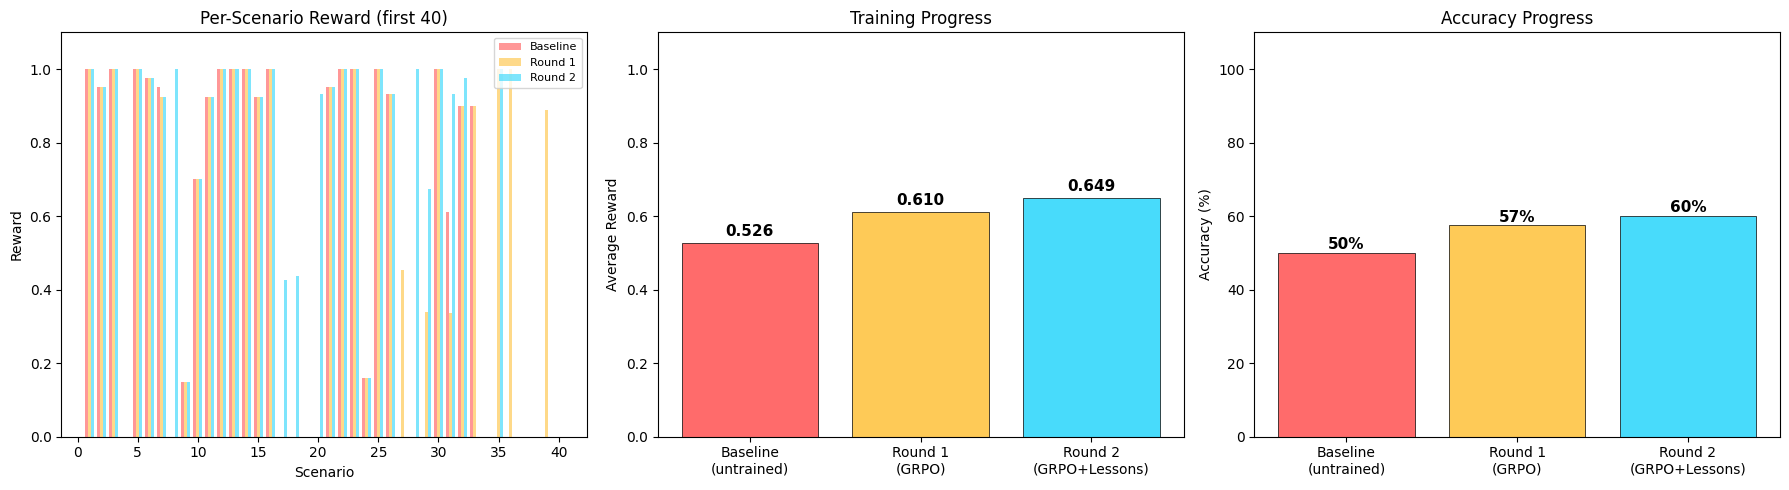

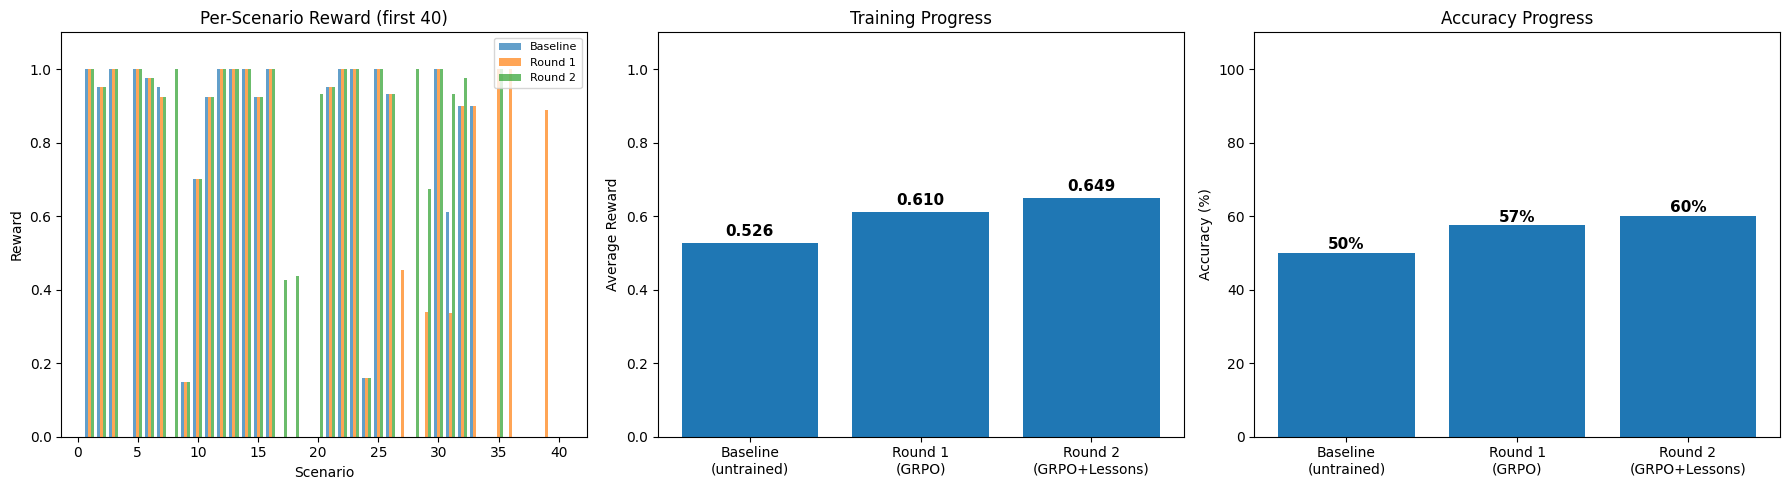

In [ ]:
# ============================================================
# CELL 16: Generate plots & save
# ============================================================
import matplotlib.pyplot as plt

# For Jupyter display
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n = min(EVAL_SCENARIOS, len(baseline_rewards))
x = range(1, n + 1)

axes[0].bar([i - 0.25 for i in x], baseline_rewards[:n], 0.25, label="Baseline", alpha=0.7)
axes[0].bar([i + 0.00 for i in x], rewards_r1[:n], 0.25, label="Round 1", alpha=0.7)
axes[0].bar([i + 0.25 for i in x], rewards_r2[:n], 0.25, label="Round 2", alpha=0.7)
axes[0].set_xlabel("Scenario")
axes[0].set_ylabe("Per-Scenario Reward (first 40)")
axes[0].legend(fol("Reward")
axes[0].set_titlentsize=8)
axes[0].set_ylim(0, 1.1)

stages = ["Baseline\n(untrained)", "Round 1\n(GRPO)", "Round 2\n(GRPO+Lessons)"]
avgs = [avg_baseline, avg_r1, avg_r2]

bars = axes[1].bar(stages, avgs)
for bar, val in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

axes[1].set_ylabel("Average Reward")
axes[1].set_title("Training Progress")
axes[1].set_ylim(0, 1.1)

accs = [acc_baseline, acc_r1, acc_r2]
bars2 = axes[2].bar(stages, [a * 100 for a in accs])
for bar, val in zip(bars2, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.0%}", ha="center", fontsize=11, fontweight="bold")

axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Accuracy Progress")
axes[2].set_ylim(0, 110)

plt.tight_layout()

# Save + Show
plt.savefig(f"{PLOTS_DIR}/training_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 17: Push to HuggingFace Hub (optional)
# ============================================================
# Uncomment and set your HF token to push the trained adapter:
#
# from huggingface_hub import login
# login(token="your_hf_token")
#
# model.push_to_hub("your-username/tool-call-grpo-qwen3b-r2")
# tokenizer.push_to_hub("your-username/tool-call-grpo-qwen3b-r2")
# print("Model pushed to HuggingFace Hub!")
#
# To also save to Google Drive:
# !cp -r ./grpo_checkpoints /content/drive/MyDrive/grpo_checkpoints
# !cp -r ./plots /content/drive/MyDrive/grpo_plots
# print("Saved to Google Drive!")